# 样条拟合

样条拟合是一种分段多项式拟合方法，核心是将整个数据区间划分为多个子区间，在每个子区间内用低阶多项式（通常是三次多项式）进行拟合，同时保证相邻子区间的多项式在连接点（称为节点）上满足平滑性约束。

简单来说，样条拟合不是用一条高次多项式去 “硬套” 所有数据点，而是用多段低次多项式拼接出一条光滑的曲线，兼顾拟合精度和曲线的平滑性。

---

## 核心原理

给定数据点 $(x_0, y_0), (x_1, y_1),..., (x_n, y_n)$，样条拟合的目标是构造一个函数 $S(x)$, 满足：

1. 分段多项式性: 在每个子区间 $[x_i, x_{i+1}]$ 上，S(x) 是一个 k 次多项式（最常用的是k=3, 即三次样条）
2. 光滑连续性：在节点 $x_j$ 处，S(x) 及其都是连续的（比如三次样条要求一阶、二阶导数连续）
3. 拟合最优性：通常通过最小化误差平方和，或者最小化曲线的 "弯曲能量" （保证曲线平滑）来确定多项式系数

最常用的类型: 三次样条拟合

三次样条拟合是工程和科研中最主流的样条，其表达式在子区间 $[x_i, x_{i+1}]$ 上为：

$$
S_i(x) = a_i + b_i(x - x_i) + c_i(x - x_i)^2 + d_i(x - x_i)^3
$$

通过节点处的连续性条件 $S(x_i^-) = S(x_i^+), S^{,}(x_i^-) = S^{,}(x_i^+)， S^{,,}(x_i^-) = S^{,,}(x_i^+)$
和边界条件（比如两端点的二阶导数为0，称为自然样条），可以解出所有系数

## 样条拟合与多项式拟合的对比

+ 函数形式
  + 多项式拟合是单一的高次多项式，
  + 样条拟合分段使用低次多项式拼接
+ 阶数选择
  + 多项式拟合：阶数k越大，越易过拟合
  + 样条拟合：固定用低阶（如3次），无过拟合风险
+ 平滑性
  + 多项式拟合：高次多项式易出现剧烈动荡
  + 样条拟合：强制节点处导数连续，曲线光滑
+ 对数据适用性
  + 适合全局趋势简单的数据
  + 适合局部趋势复杂，数据点多的场景
+ 计算复杂度
  + 低（解线性方程组）
  + 中（需要处理分段约束条件）

## 关键概念

1. 节点（Knots）
  - 数据点本身可以作为节点（插值样条，要求曲线穿过所有数据点）
  - 可以在数据点之间插入节点 (拟合样条，不要求穿过所有点，更适合含噪声的数据)
2. 边界条件
   三次样条需要边界条件才能唯一确定系数，常见类型
   + 自然边界：$S^{,,}(x_0) = 0, S^{,,}(x_n) = 0$ (曲线两端无弯曲)
   + 夹紧边界：$S^,(x_0) = f^,_0, S^,(x_n) = f^,_n$
   + 周期边界：$S(x_0) = S(x_n), S^{,}(x_0) = S^{,}(x_n), S^{,,}(x_0) = S^{,,}(x_n)$, 适合周期数据

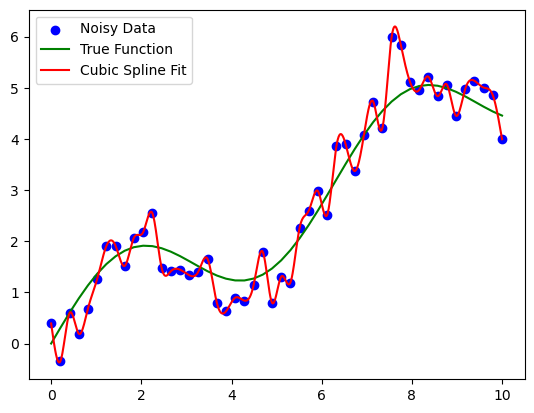

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline     # 导入三次样条插值模块 Cubic 立方体 Spline 样条

# 1. 生成带有噪音的数据
x = np.linspace(0, 10, 50)
y_true = np.sin(x) + 0.5 * x
y_noise = y_true + np.random.normal(0, 0.5, 50)

# 2. 构造三次样条（自然边界条件)
cs = CubicSpline(x, y_noise, bc_type='natural')

# 3. 生成密集点用于绘制平滑曲线
x_fine = np.linspace(0, 10, 1000)
y_fit = cs(x_fine)

# 4. 可视化结果
plt.scatter(x, y_noise, color='blue', label='Noisy Data')
plt.plot(x, y_true, color='green', label='True Function')
plt.plot(x_fine, y_fit, color='red', label='Cubic Spline Fit')
plt.legend()
plt.show()
